[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/03_rnn_lstm_gru/rnn_lstm_gru.ipynb)


# 03 . RNN, LSTM and GRU

## Concept — Recurrent networks (revision notes)

**What it is**
- A network that processes a sequence one step at a time while carrying a **hidden state** `h_t` - a fixed-size summary of everything seen so far. The *same* weights are reused at every step.
- Vanilla RNN: `h_t = tanh(W_ih x_t + b_ih + W_hh h_{t-1} + b_hh)`.
- **LSTM** adds a separate cell state `c_t` and three gates (input, forget, output) so information can be kept, written or erased explicitly.
- **GRU** is a lighter gated cell (update + reset gates, no separate cell state).

**Why it matters**
- Variable-length, ordered data (text, sensor streams, time series, music) needs a model whose size does not depend on the sequence length.
- Backpropagation through time (BPTT) multiplies the Jacobian `dh_t/dh_{t-1}` once per step. If its norm is below 1 the gradient **vanishes** exponentially; above 1 it **explodes**. Gated cells give gradients an additive path (`c_t = f*c_{t-1} + i*g`) that survives far longer.

**When to use**
- Streaming / online inference with constant memory, small time-series models, and as a clear way to learn sequence modelling ideas.
- For long-range dependencies at scale, Transformers dominate; but recurrent ideas (state-space models, RWKV, etc.) keep coming back.

**Math & intuition**
- Shapes with `batch_first=True`: input `(B, T, D)`, `output` `(B, T, H*dirs)`, `h_n` `(layers*dirs, B, H)`.
- Parameter ratio for the same sizes: RNN : GRU : LSTM = 1 : 3 : 4 (number of gate blocks).
- Exploding gradients are fixed by **clipping** (`clip_grad_norm_`); vanishing gradients by **architecture** (gates, residual connections), not by clipping.
- Variable-length batches: pad to a rectangle, then use **packed sequences** (or masks) so padding never influences the hidden state.


### 1. The RNN recurrence by hand vs nn.RNN

**What this cell does (plain language):** we write the vanilla recurrence `h_t = tanh(W_ih x_t + b_ih + W_hh h_{t-1} + b_hh)` in a Python loop using the weights of an `nn.RNN` and check that it reproduces the module's output exactly. There is no magic inside - just a loop with shared weights.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

B, T, D, H = 2, 5, 3, 4
rnn = nn.RNN(D, H, batch_first=True)          # tanh nonlinearity by default
x = torch.randn(B, T, D)
out, h_n = rnn(x)                             # out: (B,T,H)   h_n: (1,B,H)

# manual loop using the module's own weights
W_ih, W_hh, b_ih, b_hh = rnn.weight_ih_l0, rnn.weight_hh_l0, rnn.bias_ih_l0, rnn.bias_hh_l0
h = torch.zeros(B, H)                          # initial hidden state defaults to zeros
manual = []
for t in range(T):
    h = torch.tanh(x[:, t] @ W_ih.T + b_ih + h @ W_hh.T + b_hh)
    manual.append(h)
manual = torch.stack(manual, dim=1)

print("output shape:", tuple(out.shape), "| h_n shape:", tuple(h_n.shape))
print("manual loop matches nn.RNN:", torch.allclose(manual, out, atol=1e-6))
print("h_n equals the last time step of output:", torch.allclose(h_n[0], out[:, -1]))

output shape: (2, 5, 4) | h_n shape: (1, 2, 4)
manual loop matches nn.RNN: True
h_n equals the last time step of output: True


### 2. Shapes: batch_first, layers, bidirectional

**What this cell does (plain language):** the shape rules trip up almost everyone, so we print them for stacked and bidirectional LSTMs. Remember: `output` holds the LAST layer's hidden state at EVERY step, while `h_n`/`c_n` hold EVERY layer's state at the LAST step.

In [2]:
x = torch.randn(3, 7, 10)                       # (batch=3, T=7, features=10)
for layers, bi in [(1, False), (2, False), (2, True)]:
    lstm = nn.LSTM(10, 16, num_layers=layers, bidirectional=bi, batch_first=True)
    out, (h_n, c_n) = lstm(x)
    print(f"layers={layers} bidirectional={bi!s:5} -> output {tuple(out.shape)}  h_n {tuple(h_n.shape)}  c_n {tuple(c_n.shape)}")

# bidirectional: h_n[-2] is the last layer FORWARD final state, h_n[-1] is the last layer BACKWARD final state
lstm = nn.LSTM(10, 16, num_layers=2, bidirectional=True, batch_first=True)
out, (h_n, _) = lstm(x)
print("forward final state == out[:, -1, :16]:", torch.allclose(h_n[-2], out[:, -1, :16]))
print("backward final state == out[:, 0, 16:]:", torch.allclose(h_n[-1], out[:, 0, 16:]), "(backward direction finishes at t=0)")

# forgetting batch_first=True silently reinterprets dims (T, B, D)
wrong = nn.LSTM(10, 16)                         # batch_first=False
print("without batch_first, (3,7,10) is read as T=3, B=7:", tuple(wrong(x)[0].shape))

layers=1 bidirectional=False -> output (3, 7, 16)  h_n (1, 3, 16)  c_n (1, 3, 16)
layers=2 bidirectional=False -> output (3, 7, 16)  h_n (2, 3, 16)  c_n (2, 3, 16)
layers=2 bidirectional=True  -> output (3, 7, 32)  h_n (4, 3, 16)  c_n (4, 3, 16)
forward final state == out[:, -1, :16]: True
backward final state == out[:, 0, 16:]: True (backward direction finishes at t=0)
without batch_first, (3,7,10) is read as T=3, B=7: (3, 7, 16)


### 3. LSTM gates by hand and parameter counts

**What this cell does (plain language):** we step an `nn.LSTMCell` manually: the four gate pre-activations come from one big matmul that PyTorch stacks in the order input, forget, cell(g), output. We recompute the cell by hand to confirm, then compare parameter counts of RNN, GRU and LSTM of equal size.

In [3]:
torch.manual_seed(0)
cell = nn.LSTMCell(6, 8)
x_t, h0, c0 = torch.randn(2, 6), torch.randn(2, 8), torch.randn(2, 8)
h1, c1 = cell(x_t, (h0, c0))

gates = x_t @ cell.weight_ih.T + cell.bias_ih + h0 @ cell.weight_hh.T + cell.bias_hh
i, f, g, o = gates.chunk(4, dim=1)               # PyTorch order: input, forget, cell candidate, output
i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
c_manual = f * c0 + i * g                         # forget old memory, write new content (ADDITIVE update)
h_manual = o * torch.tanh(c_manual)               # expose a filtered view of the memory
print("c matches:", torch.allclose(c_manual, c1, atol=1e-6), "| h matches:", torch.allclose(h_manual, h1, atol=1e-6))

def n_params(m): return sum(p.numel() for p in m.parameters())
for name in ("RNN", "GRU", "LSTM"):
    print(f"{name:5s} params (input 16, hidden 32): {n_params(getattr(nn, name)(16, 32))}")

c matches: True | h matches: True
RNN   params (input 16, hidden 32): 1600
GRU   params (input 16, hidden 32): 4800
LSTM  params (input 16, hidden 32): 6400


### 4. Vanishing gradients, measured

**What this cell does (plain language):** we feed a random length-50 sequence into an *untrained* RNN, GRU and LSTM and compute the gradient of the final output with respect to the input at every time step. The gradient reaching early steps is the signal that would teach the model about early inputs; if it is ~0, long-range dependencies cannot be learned. We plot it on a log axis. Honest finding: with *default* initialization even the gated cells lose several orders of magnitude over 50 steps (their gates start around 0.5, so memory halves every step); the gating only becomes a real highway once the gate that keeps the old state is biased towards 1, which we also show. Gates make long memory *learnable*, not automatic.

RNN                        grad at t=T-1: 1.45e+00 | at t=0: 2.46e-14 | last/first: 5.9e+13
GRU                        grad at t=T-1: 4.69e-01 | at t=0: 1.43e-11 | last/first: 3.3e+10
LSTM                       grad at t=T-1: 1.20e-01 | at t=0: 1.08e-11 | last/first: 1.1e+10
GRU (update-gate bias +3)  grad at t=T-1: 2.28e-02 | at t=0: 2.88e-03 | last/first: 7.9e+00
LSTM (forget bias +3)      grad at t=T-1: 3.14e-01 | at t=0: 1.14e-01 | last/first: 2.8e+00


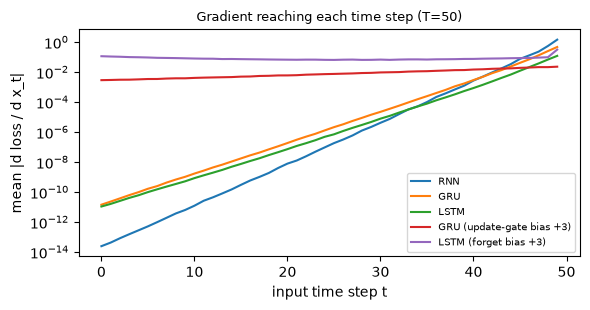

In [4]:
def grad_vs_time(kind, T=50, seed=0, hidden=32, gate_bias=0.0):
    torch.manual_seed(seed)
    m = getattr(nn, kind)(8, hidden, batch_first=True)
    if gate_bias:                                # bias the "keep the old state" gate towards 1
        H = hidden
        with torch.no_grad():
            sl = slice(H, 2*H)                   # LSTM: forget gate = 2nd block; GRU: update gate z = 2nd block
            m.bias_ih_l0[sl] = gate_bias
    x = torch.randn(64, T, 8, requires_grad=True)
    out, _ = m(x)
    out[:, -1].pow(2).sum().backward()          # loss depends only on the LAST step's output
    return x.grad.norm(dim=2).mean(0)           # (T,) mean gradient norm w.r.t. input at each step

curves = {"RNN": grad_vs_time("RNN"), "GRU": grad_vs_time("GRU"), "LSTM": grad_vs_time("LSTM"),
          "GRU (update-gate bias +3)": grad_vs_time("GRU", gate_bias=3.0),
          "LSTM (forget bias +3)": grad_vs_time("LSTM", gate_bias=3.0)}
for k, g in curves.items():
    print(f"{k:26s} grad at t=T-1: {g[-1]:.2e} | at t=0: {g[0]:.2e} | last/first: {(g[-1]/g[0]).item():.1e}")

plt.figure(figsize=(6, 3.2))
for k, g in curves.items(): plt.semilogy(g.numpy(), label=k)
plt.xlabel("input time step t"); plt.ylabel("mean |d loss / d x_t|"); plt.title("Gradient reaching each time step (T=50)", fontsize=9)
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

### 5. Exploding gradients and gradient clipping

**What this cell does (plain language):** we scale the recurrent weight matrix of an RNN so its spectral radius (here the scale, since it is a scaled orthogonal matrix) is >1 and watch the gradient norm explode, then show `clip_grad_norm_` capping it. Clipping rescales the whole gradient vector to a maximum norm, preserving its direction - it fixes *exploding*, not *vanishing*, gradients.

In [5]:
def rnn_grad_norm(scale, T=40):
    torch.manual_seed(0)
    m = nn.RNN(4, 16, batch_first=True, nonlinearity="relu")   # relu makes explosion easy to see
    with torch.no_grad():
        # orthogonal-ish recurrent matrix scaled to chosen spectral radius
        m.weight_hh_l0.copy_(torch.linalg.qr(torch.randn(16, 16))[0] * scale)
    x = torch.randn(8, T, 4)
    out, _ = m(x); out[:, -1].sum().backward()
    return m, torch.sqrt(sum(p.grad.pow(2).sum() for p in m.parameters())).item()

for scale in (0.5, 1.0, 2.0):
    _, gn = rnn_grad_norm(scale)
    print(f"recurrent scale {scale}: total grad norm = {gn:.3e}")

m, before = rnn_grad_norm(2.0)
returned = nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)   # returns the norm BEFORE clipping
after = torch.sqrt(sum(p.grad.pow(2).sum() for p in m.parameters())).item()
print(f"clip_grad_norm_ returned {returned:.3e}; norm after clipping = {after:.3f}")

recurrent scale 0.5: total grad norm = 4.510e+01
recurrent scale 1.0: total grad norm = 6.882e+01
recurrent scale 2.0: total grad norm = 3.382e+05
clip_grad_norm_ returned 3.382e+05; norm after clipping = 1.000


### 6. A synthetic memory task and a training function

**What this cell does (plain language):** the task: the label (0-3) is shown only at the very first step; the remaining steps are random distractor tokens (4-9). To answer, the model has to carry one piece of information across the whole sequence. We define the data generator and a small embedding + recurrent + linear classifier.

In [6]:
def make_recall(n, T, seed):
    g = torch.Generator().manual_seed(seed)
    y = torch.randint(0, 4, (n,), generator=g)
    x = torch.randint(4, 10, (n, T), generator=g)    # distractors
    x[:, 0] = y                                       # the only informative token
    return x, y

class SeqClassifier(nn.Module):
    def __init__(self, kind, hidden=32):
        super().__init__()
        self.emb = nn.Embedding(10, 16)
        self.rnn = getattr(nn, kind)(16, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 4)
    def forward(self, x):
        out, _ = self.rnn(self.emb(x))
        return self.fc(out[:, -1])                    # classify from the last time step

def train_recall(kind, T, steps=300, seed=0, forget_bias=0.0):
    xtr, ytr = make_recall(2048, T, seed=0); xte, yte = make_recall(512, T, seed=1)
    torch.manual_seed(seed)
    m = SeqClassifier(kind)
    if forget_bias:                                   # LSTM trick: start with forget gates mostly open
        with torch.no_grad(): m.rnn.bias_ih_l0[32:64] = forget_bias
    opt = torch.optim.Adam(m.parameters(), lr=1e-2)
    for _ in range(steps):
        idx = torch.randint(0, 2048, (64,))
        opt.zero_grad(); F.cross_entropy(m(xtr[idx]), ytr[idx]).backward()
        nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # standard safety net for recurrent nets
        opt.step()
    m.eval()
    with torch.no_grad(): return (m(xte).argmax(1) == yte).float().mean().item()

x, y = make_recall(3, 8, seed=0)
print("example sequences (first token = label):\n", x, "\nlabels:", y.tolist())
print("chance accuracy = 0.25")

example sequences (first token = label):
 tensor([[0, 5, 7, 5, 5, 5, 7, 9],
        [3, 4, 7, 8, 6, 4, 4, 6],
        [1, 6, 9, 9, 6, 6, 9, 5]]) 
labels: [0, 3, 1]
chance accuracy = 0.25


### 7. RNN vs GRU vs LSTM as the sequence gets longer

**What this cell does (plain language):** we train each cell type for the same small budget at several sequence lengths and print a table of test accuracy. The extra column initialises the LSTM forget-gate bias to 3 (the standard trick). Longer gaps are harder; with this tiny budget the results are noisy and depend on the seed (a vanilla RNN can even beat a gated cell, and which one wins at a given length can flip), so use the gradient measurements of section 4 as the principled evidence and this table as an illustration.

In [7]:
import time
t0 = time.time()
lengths = (10, 30)
names = ("RNN", "GRU", "LSTM", "LSTM fb=3")
print(f"{'T':>4} | " + " | ".join(f"{k:>9}" for k in names))
for T in lengths:
    row = [train_recall("RNN", T), train_recall("GRU", T), train_recall("LSTM", T), train_recall("LSTM", T, forget_bias=3.0)]
    print(f"{T:>4} | " + " | ".join(f"{a:9.2f}" for a in row))
print(f"(chance = 0.25; {time.time()-t0:.0f}s)")

   T |       RNN |       GRU |      LSTM | LSTM fb=3


  10 |      1.00 |      1.00 |      1.00 |      1.00


  30 |      1.00 |      0.26 |      0.27 |      1.00
(chance = 0.25; 11s)


### 8. Variable-length batches: padding and packed sequences

**What this cell does (plain language):** real batches have sequences of different lengths. We pad them to a rectangle, then use `pack_padded_sequence` so the LSTM stops at each sequence's true end. We verify that the packed `h_n` equals running every sequence alone, and show that blindly taking `out[:, -1]` of a padded batch reads the state after processing padding - a silent bug.

In [8]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
torch.manual_seed(0)

seqs = [torch.randn(5, 3), torch.randn(2, 3), torch.randn(4, 3)]      # lengths 5, 2, 4; feature dim 3
lengths = torch.tensor([len(s) for s in seqs])
padded = pad_sequence(seqs, batch_first=True)                          # (3, 5, 3), zero padded
print("padded shape:", tuple(padded.shape), "| lengths:", lengths.tolist())

lstm = nn.LSTM(3, 6, batch_first=True)
packed = pack_padded_sequence(padded, lengths, batch_first=True, enforce_sorted=False)  # lengths must be on CPU
packed_out, (h_n, c_n) = lstm(packed)
out, out_lens = pad_packed_sequence(packed_out, batch_first=True)      # back to (B, T_max, H); padding positions are 0
print("unpacked output:", tuple(out.shape), "| lengths:", out_lens.tolist())

# ground truth: run each sequence alone
alone = torch.stack([lstm(s.unsqueeze(0))[1][0][0, 0] for s in seqs])  # final h for each sequence
print("packed h_n == per-sequence runs:      ", torch.allclose(h_n[0], alone, atol=1e-6))

# the silent bug: the last row of the padded output is after the model consumed padding zeros
naive_out, _ = lstm(padded)
print("naive padded out[:, -1] == truth:      ", torch.allclose(naive_out[:, -1], alone, atol=1e-6),
      "(False for the shorter sequences)")
# the correct way without packing: gather at index length-1
idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, 6)
print("padded out gathered at length-1 == truth:", torch.allclose(naive_out.gather(1, idx).squeeze(1), alone, atol=1e-6),
      "(correct for a unidirectional LSTM, since padding comes AFTER the real tokens)")
print("padding rows in unpacked output are exactly zero:", bool((out[1, 2:] == 0).all()))

padded shape: (3, 5, 3) | lengths: [5, 2, 4]
unpacked output: (3, 5, 6) | lengths: [5, 2, 4]
packed h_n == per-sequence runs:       True
naive padded out[:, -1] == truth:       False (False for the shorter sequences)
padded out gathered at length-1 == truth: True (correct for a unidirectional LSTM, since padding comes AFTER the real tokens)
padding rows in unpacked output are exactly zero: True


### 9. Masked loss for per-step outputs, and sequence labelling

**What this cell does (plain language):** when the model predicts at every step (tagging, forecasting) padded positions must not contribute to the loss. We build a mask from the lengths and compute a masked mean, comparing it to the naive mean over padded cells. Using `ignore_index` in `cross_entropy` is the equivalent trick for class labels.

In [9]:
torch.manual_seed(0)
logits = torch.randn(3, 5, 4)                       # (B, T, classes) per-step predictions
labels = torch.randint(0, 4, (3, 5))
lengths = torch.tensor([5, 2, 4])

mask = torch.arange(5).unsqueeze(0) < lengths.unsqueeze(1)    # (B, T) True at real positions
per_tok = F.cross_entropy(logits.reshape(-1, 4), labels.reshape(-1), reduction="none").view(3, 5)
masked_mean = (per_tok * mask).sum() / mask.sum()             # average over REAL tokens only
naive_mean = per_tok.mean()                                   # wrongly includes padding cells
print("mask:\n", mask.int())
print(f"masked mean loss {masked_mean:.4f} vs naive mean {naive_mean:.4f}")

# equivalent: set padded labels to -100 and let cross_entropy ignore them
labels_ig = labels.masked_fill(~mask, -100)
ig = F.cross_entropy(logits.reshape(-1, 4), labels_ig.reshape(-1), ignore_index=-100)
print("ignore_index version matches masked mean:", torch.allclose(ig, masked_mean))

mask:
 tensor([[1, 1, 1, 1, 1],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0]], dtype=torch.int32)
masked mean loss 1.0559 vs naive mean 1.0854
ignore_index version matches masked mean: True


### 10. Time-series forecasting with an LSTM (one-step and rollout)

**What this cell does (plain language):** we train an LSTM to predict the next value of a noisy sine wave from the preceding window, then roll it out autoregressively (feeding its own predictions back in). One-step error is small; the rollout error shows how mistakes compound when the model reads its own output.

one-step MSE after training: 0.0044 (noise variance is 0.0025)
rollout RMSE over 60 steps: 0.257


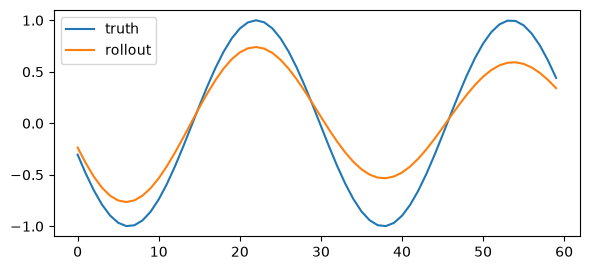

In [10]:
torch.manual_seed(0)
t = torch.arange(0, 400).float()
series = torch.sin(0.2 * t) + 0.05 * torch.randn(400)
W = 20
X = torch.stack([series[i:i+W] for i in range(300)]).unsqueeze(-1)    # (300, W, 1) windows
Y = series[W:W+300].unsqueeze(-1)                                      # next value

class Forecaster(nn.Module):
    def __init__(self):
        super().__init__(); self.lstm = nn.LSTM(1, 32, batch_first=True); self.fc = nn.Linear(32, 1)
    def forward(self, x): return self.fc(self.lstm(x)[0][:, -1])

model = Forecaster(); opt = torch.optim.Adam(model.parameters(), lr=1e-2)
for ep in range(60):
    opt.zero_grad(); loss = F.mse_loss(model(X), Y); loss.backward(); opt.step()
print(f"one-step MSE after training: {loss.item():.4f} (noise variance is 0.0025)")

# autoregressive rollout: start from a real window, then feed predictions back in
window = series[300-W:300].clone().view(1, W, 1)
preds = []
with torch.no_grad():
    for _ in range(60):
        p = model(window)
        preds.append(p.item())
        window = torch.cat([window[:, 1:], p.view(1, 1, 1)], dim=1)
truth = torch.sin(0.2 * torch.arange(300, 360).float())
print("rollout RMSE over 60 steps:", round(((torch.tensor(preds) - truth) ** 2).mean().sqrt().item(), 3))
plt.figure(figsize=(6, 2.8)); plt.plot(truth.numpy(), label="truth"); plt.plot(preds, label="rollout"); plt.legend(); plt.tight_layout(); plt.show()

## Common bugs

- **Forgetting `batch_first=True`**
  The module silently reads your `(B, T, D)` tensor as `(T, B, D)`: no error, just a model that mixes up batch and time. Fix: set `batch_first=True` or permute inputs; remember it does NOT affect the shape of `h_n` (always `(layers*dirs, B, H)`).

- **Using `out[:, -1]` on a padded batch**
  The "last" step of a short sequence is after many padding tokens, so its hidden state is polluted. Fix: pack the sequence, or gather at `lengths - 1`; for bidirectional models use `h_n`, since the backward direction starts at the padded end.

- **Passing unsorted lengths without `enforce_sorted=False`**
  `pack_padded_sequence` raises an error unless the batch is sorted by length descending. Fix: `enforce_sorted=False` (PyTorch sorts and un-sorts for you). Also `lengths` must be a CPU tensor or list.

- **Averaging the loss over padded positions**
  Padding cells dilute the loss and teach the model about meaningless tokens. Fix: masked mean or `ignore_index`; also give the embedding `padding_idx` so pad vectors stay zero.

- **Not detaching the hidden state in truncated BPTT**
  Carrying `h` across batches in a long stream keeps the whole computation graph alive: memory grows and `backward` raises "Trying to backward through the graph a second time". Fix: `h = h.detach()` (for LSTM, both `h` and `c`) at the start of each chunk.

- **Exploding gradients (loss spikes to NaN)**
  Recurrent weights get multiplied many times. Fix: `torch.nn.utils.clip_grad_norm_(params, 1.0)` after `backward()` and before `step()`; lower the learning rate.

- **Expecting clipping to fix vanishing gradients**
  Clipping only shrinks large gradients. When early steps get ~0 gradient, use LSTM/GRU, shorter sequences/truncation, skip connections, or attention.

- **Wrong initial state shape**
  `h0` must be `(layers*dirs, B, H)` and for LSTM you pass a tuple `(h0, c0)`. Fix: check `h_n.shape` of a dummy forward pass; omit `h0` for zeros.

- **Applying softmax over the time dimension by accident**
  With `(B, T, C)` outputs, `dim=-1` is classes and `dim=1` is time; mixing them gives plausible-looking but meaningless probabilities. Fix: name the dimensions in comments and test with a tiny tensor whose answer you know.

- **Taking dropout for granted**
  `nn.LSTM(dropout=p)` applies dropout only *between* stacked layers, and warns/does nothing for `num_layers=1`. Fix: add `nn.Dropout` on the outputs yourself when using one layer.


## Exercises

Attempt each one in the empty cell right after the question. A full solution is in the cell after that - don't peek until you've tried.

**Exercise 1 - Hidden state is order dependent.**
Run `nn.GRU` on a sequence and on the same sequence reversed (same weights). Show that the final hidden states differ, i.e. the model is order sensitive.

In [11]:
# Your attempt for Exercise 1 here


**Solution 1**

In [12]:
# Solution 1
torch.manual_seed(0)
gru = nn.GRU(3, 5, batch_first=True)
x = torch.randn(1, 6, 3)
_, h_fwd = gru(x); _, h_rev = gru(x.flip(1))
print(torch.allclose(h_fwd, h_rev), (h_fwd - h_rev).abs().max().item())

False 0.47294187545776367


**Exercise 2 - Reproduce GRU parameter count.**
Compute by formula the number of parameters of `nn.GRU(16, 32)` (three gates, each with input, recurrent and two bias terms) and confirm.

In [13]:
# Your attempt for Exercise 2 here


**Solution 2**

In [14]:
# Solution 2
formula = 3 * (32*16 + 32*32 + 32 + 32)
print(formula, sum(p.numel() for p in nn.GRU(16, 32).parameters()))

4800 4800


**Exercise 3 - Initial state from a context vector.**
Give an `nn.LSTM` a non-zero initial state `(h0, c0)` and verify the output changes compared with zeros.

In [15]:
# Your attempt for Exercise 3 here


**Solution 3**

In [16]:
# Solution 3
lstm = nn.LSTM(4, 8, batch_first=True)
x = torch.randn(2, 5, 4)
o_zero, _ = lstm(x)
h0, c0 = torch.randn(1, 2, 8), torch.randn(1, 2, 8)
o_ctx, _ = lstm(x, (h0, c0))
print((o_zero - o_ctx).abs().max().item() > 0)

True


**Exercise 4 - Truncated BPTT.**
Process a length-200 sequence in 4 chunks of 50, carrying the hidden state between chunks but detaching it so gradients stay within a chunk. Confirm no 'backward twice' error.

In [17]:
# Your attempt for Exercise 4 here


**Solution 4**

In [18]:
# Solution 4
lstm = nn.LSTM(1, 8, batch_first=True); head = nn.Linear(8, 1)
opt = torch.optim.Adam(list(lstm.parameters()) + list(head.parameters()), lr=1e-2)
seq = torch.sin(torch.arange(201).float() * 0.1).view(1, -1, 1)
state = None
for i in range(0, 200, 50):
    xb, yb = seq[:, i:i+50], seq[:, i+1:i+51]
    out, state = lstm(xb, state)
    loss = F.mse_loss(head(out), yb)
    opt.zero_grad(); loss.backward(); opt.step()
    state = tuple(s.detach() for s in state)       # cut the graph between chunks
    print(i, round(loss.item(), 4))

0 0.6388
50 0.4906
100 0.6391
150 0.434


**Exercise 5 - Pack, run, take the last real state.**
Write a function `last_hidden(lstm, padded, lengths)` that returns the correct final hidden state for each sequence using packing, and test it against a per-sequence loop.

In [19]:
# Your attempt for Exercise 5 here


**Solution 5**

In [20]:
# Solution 5
def last_hidden(lstm, padded, lengths):
    packed = pack_padded_sequence(padded, lengths, batch_first=True, enforce_sorted=False)
    _, (h_n, _) = lstm(packed)
    return h_n[-1]                                  # last layer, (B, H)

lstm = nn.LSTM(3, 6, batch_first=True)
seqs = [torch.randn(4, 3), torch.randn(2, 3)]
padded = pad_sequence(seqs, batch_first=True); lens = torch.tensor([4, 2])
ref = torch.stack([lstm(s.unsqueeze(0))[1][0][0, 0] for s in seqs])
print(torch.allclose(last_hidden(lstm, padded, lens), ref, atol=1e-6))

True


**Exercise 6 - Forget-gate bias trick.**
LSTM forget gates start near 0.5 after default init. Set the forget-gate bias to 1 (slice `[H:2H]` of each bias vector) and compare the mean gradient norm at t=0 with the default init (use the helper idea from section 4).

In [21]:
# Your attempt for Exercise 6 here


**Solution 6**

In [22]:
# Solution 6
def first_step_grad(init_forget_bias, T=50, H=32):
    torch.manual_seed(0)
    m = nn.LSTM(8, H, batch_first=True)
    if init_forget_bias:
        with torch.no_grad():
            m.bias_ih_l0[H:2*H].fill_(1.0); m.bias_hh_l0[H:2*H].fill_(1.0)   # sigmoid(2) ~ 0.88
    x = torch.randn(64, T, 8, requires_grad=True)
    m(x)[0][:, -1].pow(2).sum().backward()
    return x.grad.norm(dim=2).mean(0)[0].item()
print("default:", first_step_grad(False), "| forget bias 1:", first_step_grad(True))

default: 1.0827747552732969e-11 | forget bias 1: 0.01017049327492714


**Exercise 7 - Bidirectional for tagging.**
Build a bidirectional GRU tagger that outputs a class score per time step. What is the input size of the final `Linear` layer?

In [23]:
# Your attempt for Exercise 7 here


**Solution 7**

In [24]:
# Solution 7
class Tagger(nn.Module):
    def __init__(self, d=8, h=16, c=5):
        super().__init__()
        self.rnn = nn.GRU(d, h, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2*h, c)               # forward and backward states are concatenated
    def forward(self, x): return self.fc(self.rnn(x)[0])
print(Tagger()(torch.randn(3, 9, 8)).shape)       # (B, T, classes)

torch.Size([3, 9, 5])
